In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn import metrics
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [165]:
# Read data from file
raw_df = pd.read_csv('marketing_campaign.csv', sep='\t')
raw_df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [166]:
# Dataframe main info
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**Observations:**
- 2240 entries
- 28 features (excluding ID)
    - 24 int, 1 float and 3 object columns
- only column `Income` has missed values

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [167]:
# Show statistics for Income column
raw_df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

Mean and median are pretty close to each other and also we work a lot with KMeans clasterization in this HW, so it makes sense to fill in missed values with mean value.

In [168]:
# Fill in missed values with mean value
raw_df['Income'] = raw_df['Income'].fillna(raw_df['Income'].mean())
raw_df['Income'].isna().sum()

np.int64(0)

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [169]:
# Show object column values
categorical_cols = raw_df.select_dtypes(include='object').columns.to_list()
for col in categorical_cols:
    print(raw_df[col].value_counts())
    print('\n')

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Dt_Customer
31-08-2012    12
12-09-2012    11
14-02-2013    11
12-05-2014    11
20-08-2013    10
              ..
05-08-2012     1
18-11-2012     1
25-05-2013     1
14-04-2013     1
09-01-2014     1
Name: count, Length: 663, dtype: int64




**Summary:**
- `Education` can be encoded as ordered column, but `2n Cycle` should be merged into `Master`
- `Marital_Status` has incorrect values, which should be replaced or dropped, and then it can be encoded with OneHotEncoder
- `Dt_Customer` is a date, can be transformed to a number of days from now

In [170]:
# Transfrom 'Alone' to 'Single'
# and remove istances with 'Absurd' and 'YOLO'
raw_df['Marital_Status'] = raw_df['Marital_Status'].replace({
    'Alone': 'Single'
})
raw_df = raw_df[~raw_df['Marital_Status'].isin(['Absurd', 'YOLO'])]
raw_df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      483
Divorced    232
Widow        77
Name: count, dtype: int64

In [171]:
# Encode Marital_Status with OneHotEncoder
oh_encoder = OneHotEncoder(sparse_output=False)
oh_encoder.fit(raw_df[['Marital_Status']])

encoded_cols = oh_encoder.get_feature_names_out().tolist()

encoded_df = pd.DataFrame(
        oh_encoder.transform(raw_df[['Marital_Status']]),
        columns=encoded_cols,
        index=raw_df.index
)

# Replace categorical column with encoded ones
raw_df = pd.concat([raw_df, encoded_df], axis=1)
raw_df = raw_df.drop('Marital_Status', axis=1)
raw_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow'],
      dtype='object')

In [172]:
# Merge '2n Cycle' into 'Master'
raw_df['Education'] = ['Master' if x=='2n Cycle' else x for x in raw_df['Education']]
raw_df['Education'].value_counts()

Education
Graduation    1126
Master         572
PhD            484
Basic           54
Name: count, dtype: int64

In [173]:
# Encode Education with OneHotEncoder
ord_encoder = OrdinalEncoder(categories=[['Basic', 'Graduation', 'Master', 'PhD']])
raw_df['Education'] = ord_encoder.fit_transform(raw_df[['Education']])
raw_df['Education'].value_counts()

Education
1.0    1126
2.0     572
3.0     484
0.0      54
Name: count, dtype: int64

In [174]:
hoho = pd.to_datetime(raw_df['Dt_Customer'], format='%d-%m-%Y')
hoho.min()

Timestamp('2012-07-30 00:00:00')

In [175]:
# Transform 'Dt_Customer' date column
transformed_dates = pd.to_datetime(raw_df['Dt_Customer'], format='%d-%m-%Y')
max_date = transformed_dates.max()

raw_df['Dt_Customer'] = (max_date - transformed_dates).dt.days
raw_df['Dt_Customer']

0       663
1       113
2       312
3       139
4       161
       ... 
2235    381
2236     19
2237    155
2238    156
2239    622
Name: Dt_Customer, Length: 2236, dtype: int64

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [176]:
# Copy data to variable X
X = raw_df.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis=1).copy()
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year_Birth               2236 non-null   int64  
 1   Education                2236 non-null   float64
 2   Income                   2236 non-null   float64
 3   Kidhome                  2236 non-null   int64  
 4   Teenhome                 2236 non-null   int64  
 5   Dt_Customer              2236 non-null   int64  
 6   Recency                  2236 non-null   int64  
 7   MntWines                 2236 non-null   int64  
 8   MntFruits                2236 non-null   int64  
 9   MntMeatProducts          2236 non-null   int64  
 10  MntFishProducts          2236 non-null   int64  
 11  MntSweetProducts         2236 non-null   int64  
 12  MntGoldProds             2236 non-null   int64  
 13  NumDealsPurchases        2236 non-null   int64  
 14  NumWebPurchases          2236

**There is a lot of columns, let's make additional preprocessing to make number of them smaller.**

In [177]:
# Replace all Mnt columns with Total
mnt_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]
X['MntTotal'] = X[mnt_cols].sum(axis=1)
X.drop(columns=mnt_cols, inplace=True)

In [178]:
# Merge Kidhome and Teenhome
child_cols = ['Kidhome', 'Teenhome']
X['Childhome'] = X[child_cols].sum(axis=1)
X.drop(columns=child_cols, inplace=True)

In [179]:
# Replace AcceptedCmp columns with Total
cmp_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]
X['AcceptedCmpTotal'] = X[cmp_cols].sum(axis=1)
X.drop(columns=cmp_cols, inplace=True)

In [180]:
# Transform Marital_Status columns to one binary column
has_pair_cols = ['Marital_Status_Married', 'Marital_Status_Together']
no_pair_cols = ['Marital_Status_Divorced', 'Marital_Status_Single', 'Marital_Status_Widow']

X['Marital_Status_HasPair'] = X[has_pair_cols].any(axis=1).astype(int)
X.drop(columns=[*has_pair_cols, *no_pair_cols], inplace=True)

In [181]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year_Birth              2236 non-null   int64  
 1   Education               2236 non-null   float64
 2   Income                  2236 non-null   float64
 3   Dt_Customer             2236 non-null   int64  
 4   Recency                 2236 non-null   int64  
 5   NumDealsPurchases       2236 non-null   int64  
 6   NumWebPurchases         2236 non-null   int64  
 7   NumCatalogPurchases     2236 non-null   int64  
 8   NumStorePurchases       2236 non-null   int64  
 9   NumWebVisitsMonth       2236 non-null   int64  
 10  Complain                2236 non-null   int64  
 11  Response                2236 non-null   int64  
 12  MntTotal                2236 non-null   int64  
 13  Childhome               2236 non-null   int64  
 14  AcceptedCmpTotal        2236 non-null   int64

In [182]:
# Make clusterization
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

labels = kmeans.predict(X)
labels

array([0, 1, 0, ..., 0, 0, 0], shape=(2236,), dtype=int32)

In [183]:
# Calculate the Silhouette score
sil_score = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette score is {sil_score:.2f}')

Silhouette score is 0.60


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

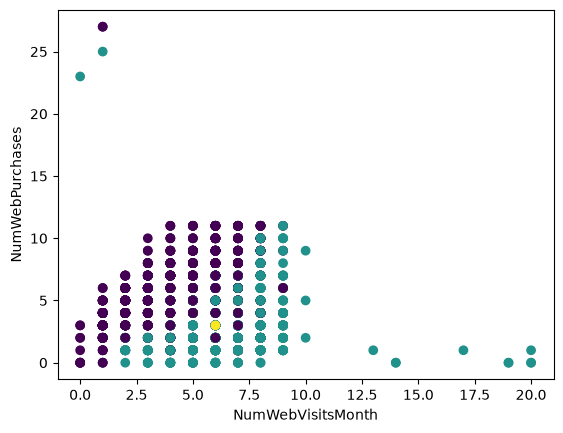

In [187]:
# Visualize clustering results for 2 features
plt.scatter(X['NumWebVisitsMonth'], X['NumWebPurchases'], c=labels)
plt.xlabel('NumWebVisitsMonth')
plt.ylabel('NumWebPurchases')
plt.show()

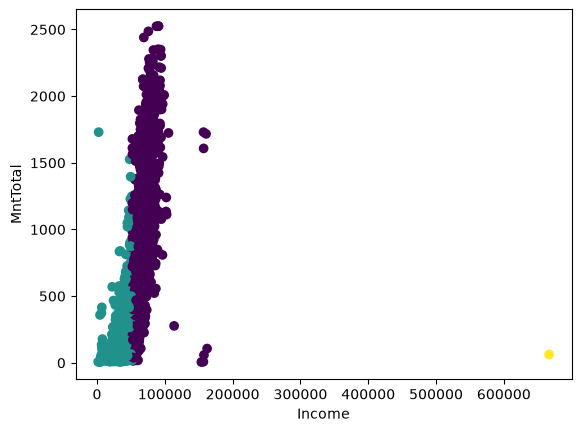

In [188]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['MntTotal'], c=labels)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

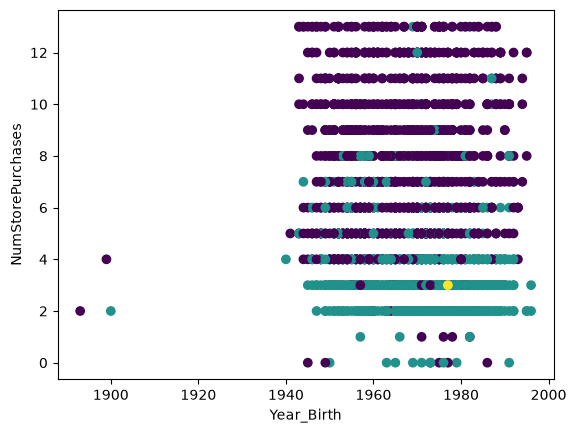

In [193]:
# Visualize clustering results for 2 features
plt.scatter(X['Year_Birth'], X['NumStorePurchases'], c=labels)
plt.xlabel('Year_Birth')
plt.ylabel('NumStorePurchases')
plt.show()

**Summary.** Different clusters are closely packed together and one of the clusters has just one entry. So this clustering has no sense.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [194]:
# Scale values of all the features
std_scaler = StandardScaler()
X[X.columns] = std_scaler.fit_transform(X)

In [195]:
# Make clusterization
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X)

# Calculate the Silhouette score
sil_score = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette score is {sil_score:.2f}')

Silhouette score is 0.16


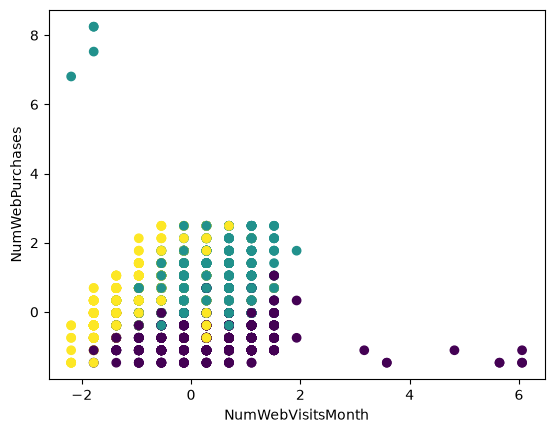

In [196]:
# Visualize clustering results for 2 features
plt.scatter(X['NumWebVisitsMonth'], X['NumWebPurchases'], c=labels)
plt.xlabel('NumWebVisitsMonth')
plt.ylabel('NumWebPurchases')
plt.show()

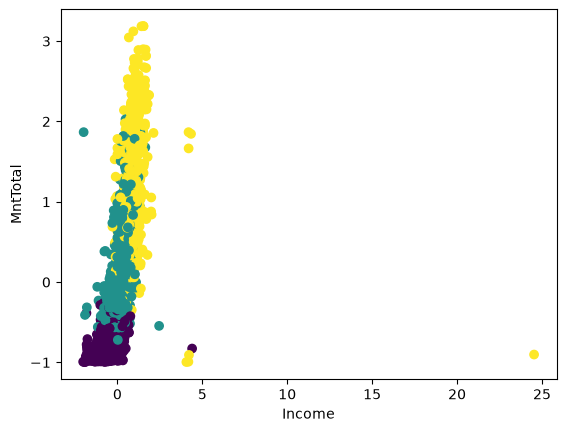

In [197]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['MntTotal'], c=labels)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

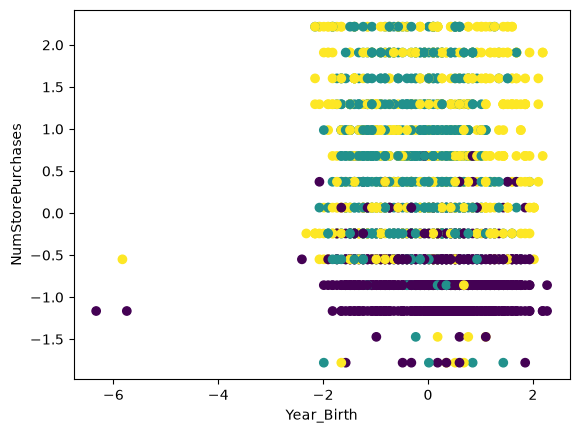

In [198]:
# Visualize clustering results for 2 features
plt.scatter(X['Year_Birth'], X['NumStorePurchases'], c=labels)
plt.xlabel('Year_Birth')
plt.ylabel('NumStorePurchases')
plt.show()

**Summary.** Results of clustering are very similar to the previous experiment. Silhouette score is much worse, probably because scaling made it more "honest".

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [199]:
# Remove some of the outliers based on previous experiment
X = X[~(X['NumWebPurchases'] > 6)]
X = X[~(X['NumWebVisitsMonth'] > 4)]
X = X[~(X['Income'] > 10)]
X = X[~(X['Year_Birth'] < -4)]
X.shape

(2222, 16)

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

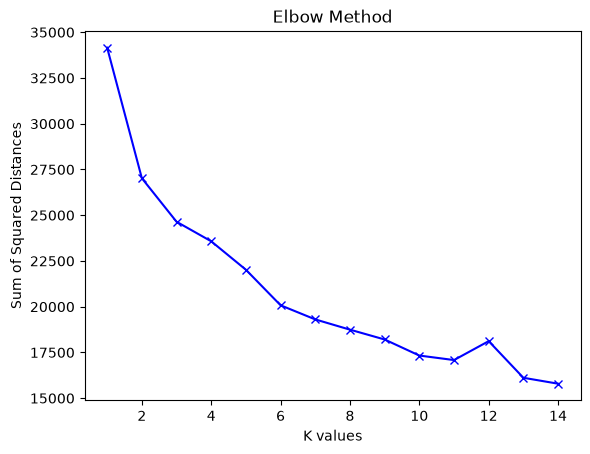

In [201]:
# Search for optimal k with Elbow method
k_range = range(1, 15)
sum_of_squared_distances = []

for k in k_range:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(k_range, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [202]:
# Make clusterization
kmeans = KMeans(n_clusters=6)
kmeans.fit(X)
labels = kmeans.predict(X)

# Calculate the Silhouette score
sil_score = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette score is {sil_score:.2f}')

Silhouette score is 0.12


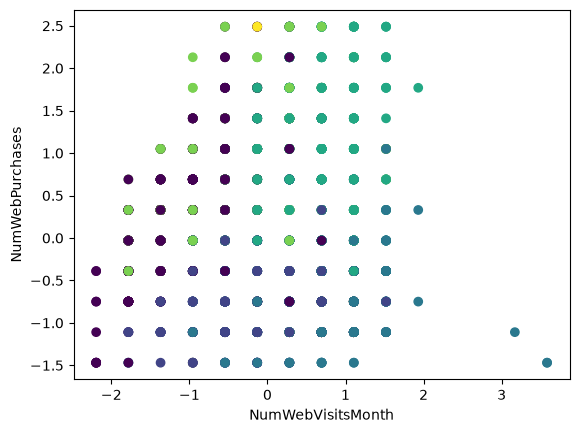

In [203]:
# Visualize clustering results for 2 features
plt.scatter(X['NumWebVisitsMonth'], X['NumWebPurchases'], c=labels)
plt.xlabel('NumWebVisitsMonth')
plt.ylabel('NumWebPurchases')
plt.show()

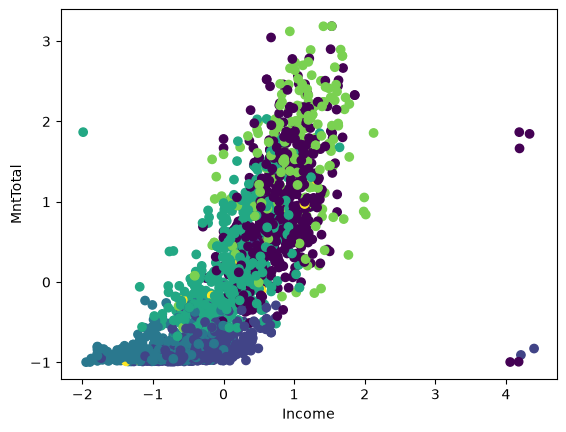

In [204]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['MntTotal'], c=labels)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

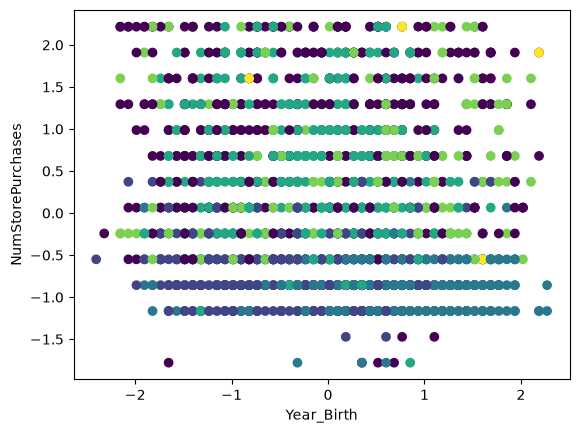

In [205]:
# Visualize clustering results for 2 features
plt.scatter(X['Year_Birth'], X['NumStorePurchases'], c=labels)
plt.xlabel('Year_Birth')
plt.ylabel('NumStorePurchases')
plt.show()

**Summary.** Elbow method didn't make clustering better. Probably it's because of a lot of features create noise and it's hard to do meaningful clustering.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

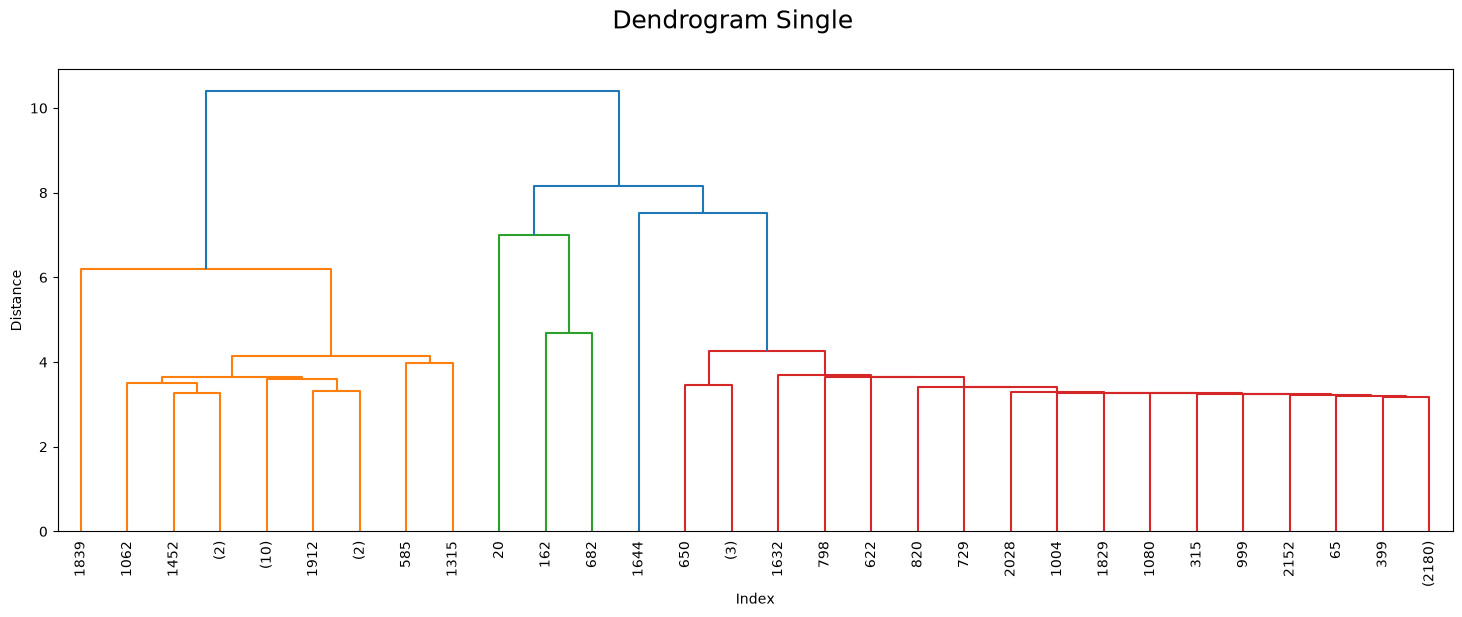

In [211]:
dist_sin = linkage(X, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single", fontsize=18)
plt.show()

In [212]:
clust_2 = fcluster(dist_sin, 2, criterion='maxclust')
clust_3 = fcluster(dist_sin, 3, criterion='maxclust')

**For 2-cluster**

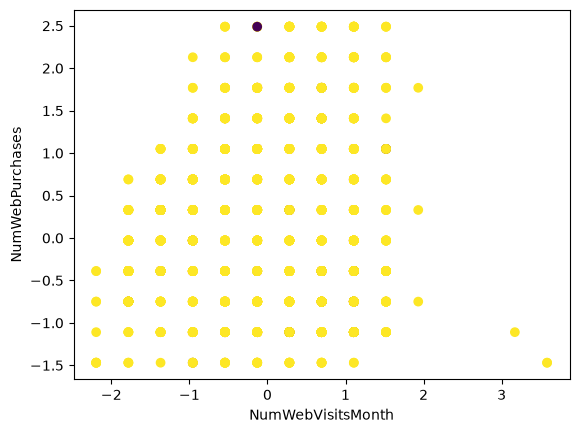

In [217]:
# Visualize clustering results for 2 features
plt.scatter(X['NumWebVisitsMonth'], X['NumWebPurchases'], c=clust_2)
plt.xlabel('NumWebVisitsMonth')
plt.ylabel('NumWebPurchases')
plt.show()

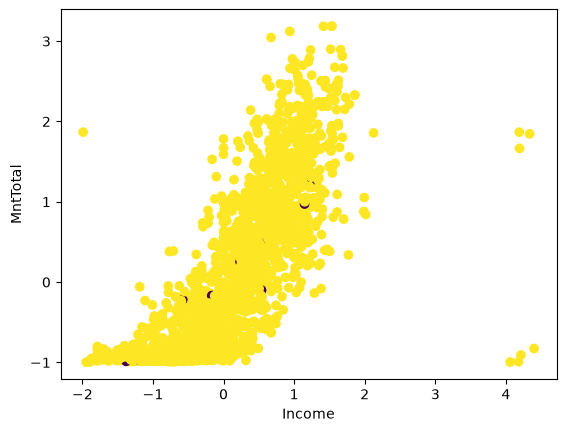

In [218]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['MntTotal'], c=clust_2)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

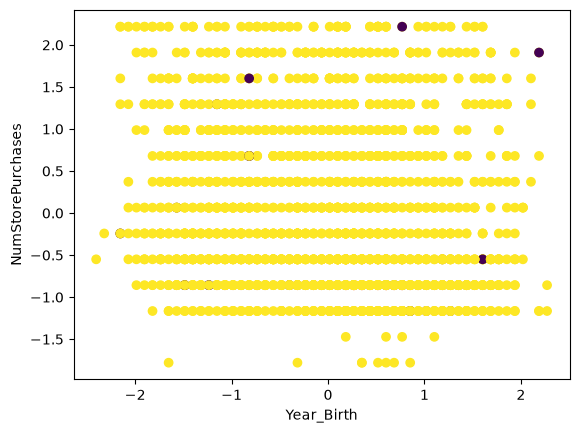

In [219]:
# Visualize clustering results for 2 features
plt.scatter(X['Year_Birth'], X['NumStorePurchases'], c=clust_2)
plt.xlabel('Year_Birth')
plt.ylabel('NumStorePurchases')
plt.show()

**For 3-cluster**

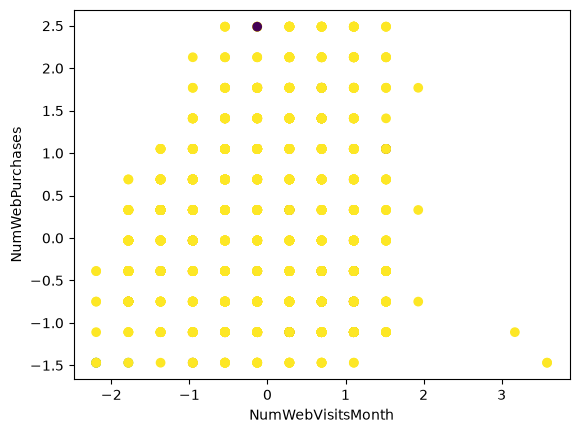

In [220]:
# Visualize clustering results for 2 features
plt.scatter(X['NumWebVisitsMonth'], X['NumWebPurchases'], c=clust_3)
plt.xlabel('NumWebVisitsMonth')
plt.ylabel('NumWebPurchases')
plt.show()

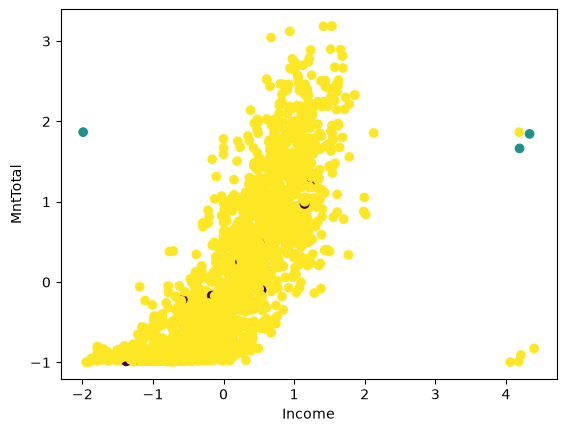

In [221]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['MntTotal'], c=clust_3)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

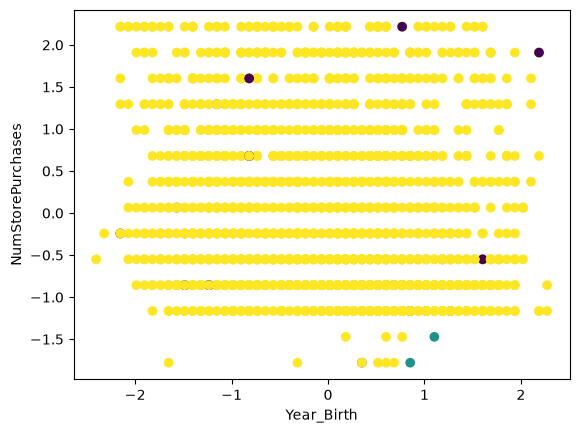

In [222]:
# Visualize clustering results for 2 features
plt.scatter(X['Year_Birth'], X['NumStorePurchases'], c=clust_3)
plt.xlabel('Year_Birth')
plt.ylabel('NumStorePurchases')
plt.show()

**Summary.** Visualizations for both 2-cluster and 3-cluster didn't bring any clarity. The reason is the same - too many features.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [232]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan.fit(X)
labels = dbscan.labels_
set(labels)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}

In [233]:
sil_score = metrics.silhouette_score(X, labels)
print(f'Silhouette score is {sil_score:.2f}')

Silhouette score is -0.22


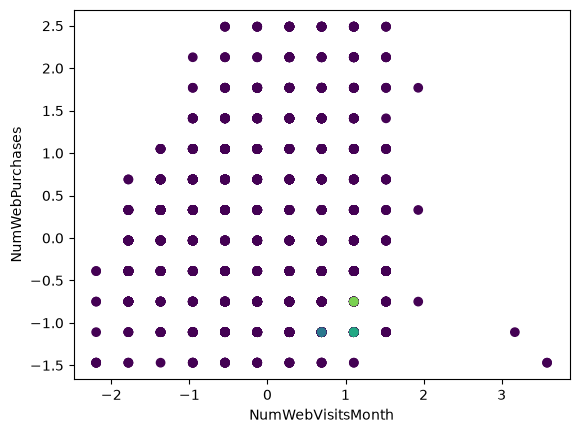

In [234]:
# Visualize clustering results for 2 features
plt.scatter(X['NumWebVisitsMonth'], X['NumWebPurchases'], c=labels)
plt.xlabel('NumWebVisitsMonth')
plt.ylabel('NumWebPurchases')
plt.show()

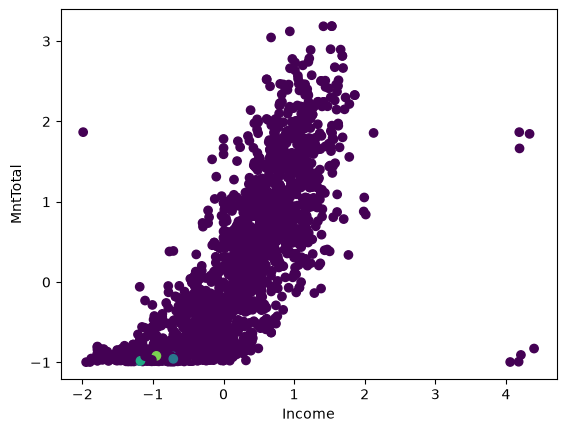

In [235]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['MntTotal'], c=labels)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

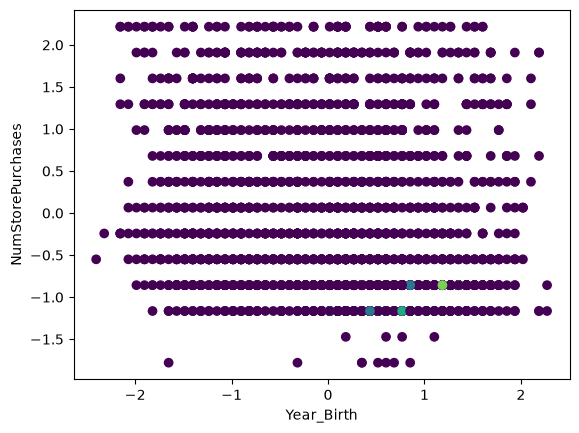

In [236]:
# Visualize clustering results for 2 features
plt.scatter(X['Year_Birth'], X['NumStorePurchases'], c=labels)
plt.xlabel('Year_Birth')
plt.ylabel('NumStorePurchases')
plt.show()

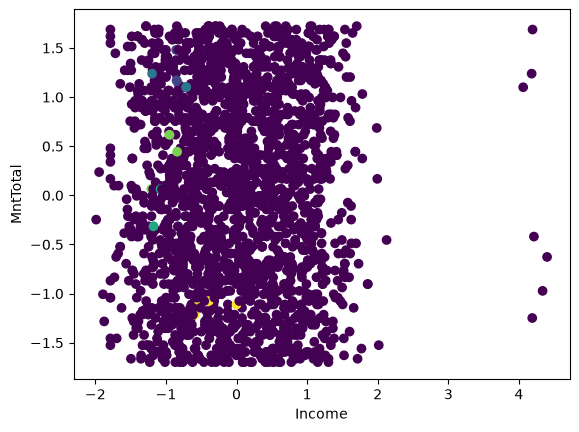

In [248]:
# Visualize clustering results for 2 features
plt.scatter(X['Income'], X['Recency'], c=labels)
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

**Summary.** DBSCAN showed even worse clusterization with Silhouette score equal to -0.22. We need to reduce dimensions first to see proper results.